# Ejercicio de clase: Predicción del precio de vivienda con Decision Tree Regressor

**Dataset**: California Housing Prices — https://www.kaggle.com/datasets/camnugent/california-housing-prices

En el ejemplo de clase (`decision_tree_example.ipynb`) usamos un **Decision Tree Classifier** para predecir
si un paciente sobrevivía o no a una sepsis. Esa era una tarea de **clasificación**: la variable que
queríamos predecir (`hospital_outcome`) solo podía tomar un número limitado de valores (0 o 1, "vive" o
"muere").

En este ejercicio vamos a resolver un problema distinto: **regresión**. Vamos a predecir el **precio
mediano de una vivienda** (`median_house_value`) en un bloque censal de California, a partir de
características como la ubicación, la cantidad de habitaciones o el ingreso medio de sus habitantes.

> **Diferencia clave**: en clasificación el modelo predice una *categoría* (una clase). En regresión el
> modelo predice un *número real* (puede tomar, en principio, cualquier valor dentro de un rango continuo).
> Esto tiene consecuencias importantes: no podemos usar métricas como *precision*, *recall* o *F1*, porque
> esas métricas comparan clases exactas. En su lugar usaremos métricas que midan **qué tan lejos** está la
> predicción del valor real, como el **MAE (Mean Absolute Error)**, que veremos más adelante.

Para este ejercicio usarán `DecisionTreeRegressor` en lugar de `DecisionTreeClassifier`.

### Antes de empezar

1. Descarguen el dataset desde Kaggle: https://www.kaggle.com/datasets/camnugent/california-housing-prices
2. El archivo se llama `housing.csv`. Colóquenlo dentro de la carpeta `raw/` de este proyecto
   (la misma carpeta `decision_tree/raw/` donde está el dataset de sepsis).
3. Sigan cada sección en orden. Cada sección tiene:
   - Una breve explicación de qué vamos a hacer y por qué.
   - Un **reto**: ustedes deben escribir el código (no está resuelto).
   - **Preguntas de análisis**: respóndanlas en una celda de markdown justo debajo de su código.


### Importar librerías

Igual que en el ejemplo de clase, empezamos importando las librerías que vamos a necesitar. Noten dos
diferencias frente al ejemplo de clasificación:

- Usamos `DecisionTreeRegressor` en lugar de `DecisionTreeClassifier`.
- Usamos `mean_absolute_error` en lugar de `precision_score`, `recall_score`, `f1_score`.


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error


## Paso 1 — Cargar los datos

**Reto**: Carguen el archivo `housing.csv` (carpeta `raw/`) en un DataFrame de pandas llamado `df`, tal
como hicimos en el ejemplo de clase con `pd.read_csv(...)`. Luego muestren las primeras filas del
DataFrame para confirmar que se cargó correctamente.


In [27]:
# TODO: cargar el dataset en un DataFrame llamado df
df = pd.read_csv("raw/housing.csv")


In [30]:
# TODO: mostrar las primeras filas del DataFrame
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [31]:
df.shape

(20640, 10)

**Preguntas de análisis**
1. ¿Cuántas filas y cuántas columnas tiene el dataset? (pista: `df.shape`)
2. ¿Qué representa cada fila del dataset? ¿Es una vivienda individual o algo distinto?
3. Observando los nombres de las columnas, ¿cuál creen que es la variable que vamos a predecir (el
   *target*)?
### Respuesta
1. El dataset esta compuesto de 20640 filas y 10 columnas.
2. por los nombres de las columnas y las cantidades dentro de las filas lo mas probable es que sean conjuntos de casa probablemente en una zona cercana como un conjunto recidencial o una cuadra.
3. yo pensaria que el valor mas importante a predecir puede ser el valor de la casa por lo que diria que median_house_value aunque creo que cualquiara se podria predecir.


## Paso 2 — Identificación inicial de los datos

Antes de tocar cualquier dato, siempre debemos entender con qué estamos trabajando: cuántas columnas hay,
qué tipo de dato tiene cada una, si hay valores nulos, y cuál es el rango de valores de cada variable.

**Reto**: Usando lo que ya conocen de pandas, respondan (con código) estas tres preguntas:
1. ¿Qué tipo de dato (`dtype`) tiene cada columna? ¿Hay alguna columna categórica (texto)?
2. ¿Cuáles son las estadísticas básicas (media, desviación estándar, mínimo, máximo, etc.) de las
   columnas numéricas?
3. ¿Hay valores nulos (faltantes) en el dataset? ¿En qué columna(s)?

Pistas de los métodos que necesitan (ya los usamos, en otra forma, en el ejemplo de clase): `.info()`,
`.describe()`, `.isnull()`.


In [32]:
# TODO: tipos de dato de cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [33]:
# TODO: estadísticas descriptivas de las columnas numéricas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [37]:
# TODO: cantidad de valores nulos por columna
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [38]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [39]:
(df['median_house_value'] == 500001).sum()

np.int64(965)

**Preguntas de análisis**
1. ¿Cuál es la única columna categórica (de texto) del dataset? ¿Qué valores puede tomar?
2. ¿Qué columna tiene valores nulos? ¿Cuántas filas están afectadas, aproximadamente qué porcentaje del
   total representa?
3. Miren el `min` y el `max` de `median_house_value`. ¿Les parece un rango razonable para el precio de una
   vivienda? ¿Notan algo raro en el valor máximo? (pista: busquen cuántas filas tienen exactamente ese
   valor máximo).
4. Comparen el rango de `median_income` con el de `total_rooms`. ¿Están en escalas muy distintas? ¿Creen
   que eso sería un problema para un Decision Tree? (piensen en cómo el árbol elige los cortes: ¿necesita
   que las variables estén en la misma escala, como sí lo necesitan otros modelos?)
### respuestas
1.  9   ocean_proximity     20640 non-null  object , es la unica que es texto, sus posibles valores son: <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY, ISLAND.
2. total_bedrooms	207, es la unica columna con valores nulos y sus 207 valores nulos representan un poco mas del 1%.
3. los precios medios de las casas van entre $14,999 dolares hasta $500,001 dolares y aparecen mas de 900 casas con un valor medio de $500,001 por lo que lo mas probable es que este sea el valor maximo que tomaron en el dataset, como se puede ver la grafica funciona de manera irregular al no seguir una distribucion normal que seria lo esperado ya que al final aumenta demasiado, por lo que probablemente nuestra hipotesis sea la correcta.

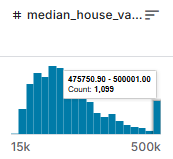

4. mientras que median_income va desde 0.4999 a 15.000100, por lo que podemos supones que son valores dividos por 10.000 para simplicidad, total_rooms en cambio va desde 2 hasta 39320, por lo que probablemente este sea el numero directamente de piezas. esto no deberia afectar un arbol de decicion ya que realiza cortes de umbral con Xi<umbral por lo que las escalas no afectan.

## Paso 3 — Procesamiento de datos

Por ahora, para mantener el ejercicio simple, vamos a trabajar **solo con variables numéricas**. Más
adelante en el curso aprenderemos técnicas para incorporar variables categóricas (como *one-hot encoding*),
pero hoy las vamos a descartar.

**Reto**:
1. Eliminen del DataFrame la(s) columna(s) categórica(s) que identificaron en el paso anterior.
2. Decidan qué hacer con los valores nulos que encontraron (por ejemplo, eliminar esas filas) y
   apliquen esa decisión. Un Decision Tree Regressor de scikit-learn no puede entrenarse si quedan
   valores `NaN` en los datos.
3. Confirmen, con código, que ya no quedan columnas categóricas ni valores nulos.


In [40]:
# TODO: eliminar la(s) columna(s) categórica(s)
df_num = df.drop(columns=['ocean_proximity'])


In [41]:
# TODO: manejar los valores nulos (por ejemplo, eliminarlos)
df_num = df_num.dropna()


In [42]:
# TODO: confirmar que no quedan nulos ni columnas categóricas
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


**Preguntas de análisis**
1. ¿Qué información de las viviendas estamos perdiendo al eliminar la columna categórica? ¿Creen que esa
   información podría ser útil para predecir el precio? ¿Por qué?
2. Si eliminaron filas con nulos, ¿cuántas filas quedaron en total? ¿Qué porcentaje del dataset original
   se perdió?
3. ¿Qué otra estrategia (distinta a eliminar las filas) existe para tratar valores nulos? ¿Por qué hoy
   optamos por la más simple?
## Respusta
1. yo creo que esa informacion puede ser importante para predecir el precio especialmente sabiendo que el dataset esta basado en viviendas en california donde la cercania al mar aumenta o disminuye el precio de la vivienda bastante.
2. quedamos con 20433 filas en comparacion de las originales 20,640 por lo que pedimos aproximadamente el 1% del dataset
3. podriamos remplazar estos valores nulos por la media de los datos de esa columna para que no afecte de manera drastica el modelo, y creo que decidimos eliminar en vez de buscar otras estrategias ya que el porcentaje perdido es tan bajo siendo un poco mas de 1%.


## Paso 4 — Definir variables predictoras (X) y variable objetivo (y), y dividir los datos

Igual que en el ejemplo de clase, necesitamos separar:
- **X**: las columnas que el modelo usará para predecir (todas menos el precio).
- **y**: la columna que queremos predecir (`median_house_value`).

Y luego dividir ambas en un conjunto de **entrenamiento** y uno de **prueba**, usando
`train_test_split`, tal como hicimos con los datos de sepsis.

**Reto**:
1. Construyan `X` (todas las columnas numéricas excepto `median_house_value`) y `y`
   (`median_house_value`).
2. Usen `train_test_split` para crear `X_train`, `X_test`, `y_train`, `y_test`. Usen un `test_size` de
   0.2 y `random_state=0` para que los resultados sean reproducibles.


In [43]:
# TODO: construir X (predictoras) y y (target)
X = df_num.drop(columns=['median_house_value'])
y = df_num['median_house_value']

In [44]:
# TODO: dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [45]:
len(X_train)

16346

In [46]:
len(X_test)

4087

**Preguntas de análisis**
1. ¿Cuántas filas quedaron en `X_train` y cuántas en `X_test`?
2. ¿Por qué es importante evaluar el modelo en datos que **no** usó para entrenar (`X_test`, `y_test`)?
   ¿Qué pasaría si evaluáramos únicamente sobre `X_train`?
3. En el ejemplo de clase balanceamos las clases con SMOTE antes de dividir los datos. Aquí no lo hicimos.
   ¿Por qué SMOTE (que genera ejemplos sintéticos de una *clase* minoritaria) no tiene sentido en un
   problema de regresión, donde no hay clases sino un valor continuo?
### Respuestas
1. En X_train quedaron 16346 que es el 80% del dataset mientras que en X_test quedo el 20% restante que corresponde a 4087.
2. esto podria generar un overfitting, por lo que aunque en el testing los datos aparezcan demasiado buenos a la hora de entrarle datos nuevos es muy probable que de resultados incorrectos o impredecibles.
3. ya que estamos resolviendo un problema de regresion no tiene sentido ya que SMOTE es para problemas de clasificacion, por lo que simplemente no funcionaria ya que SMOTE necesita clases discretas por lo que no encontraria una *clase* minoritaria.

## Paso 5 — Entrenar el Decision Tree Regressor

**Reto**: Entrenen un `DecisionTreeRegressor` (con `random_state=0`) usando `X_train` y `y_train`, de la
misma forma en que entrenaron el `DecisionTreeClassifier` en el ejemplo de clase.


In [47]:
# TODO: crear y entrenar el modelo
reg = DecisionTreeRegressor(random_state=0)
reg.fit(X_train, y_train)


DecisionTreeRegressor(random_state=0)

In [49]:
print(reg.criterion)

squared_error


**Preguntas de análisis**
1. En clasificación, cada hoja del árbol predice una clase (por ejemplo, "vive" o "muere"). En regresión,
   ¿qué creen que predice cada hoja del árbol? (pista: piensen en los valores de `y` que caen en esa
   hoja durante el entrenamiento).
2. ¿Qué criterio usa por defecto `DecisionTreeRegressor` para decidir dónde hacer cada corte, en lugar del
   *gini* o *entropy* que se usan en clasificación? (revisen la documentación del parámetro `criterion`).
   # respuesta
   1. cada hoja predice un numero el cual corresponde al valor promedio de los valores del objetivo, en este caso median_house_value.
   2. por defecto usa el error cuadratico medio o squared_error el cual mide la distacia entre el valor real y el calculado.


## Paso 6 — Evaluar el modelo con MAE

### ¿Qué es el MAE (Mean Absolute Error)?

El **MAE** es el promedio de la diferencia absoluta entre el valor real y el valor predicho:

$$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

A diferencia de precision/recall/F1 (que solo tienen sentido cuando comparamos clases), el MAE funciona
sobre valores numéricos continuos y nos dice, **en promedio, cuánto se equivoca el modelo, en las mismas
unidades que la variable objetivo**. En nuestro caso, como `median_house_value` está en dólares, un
MAE de, por ejemplo, 40000 significa que en promedio el modelo se equivoca en $40,000 dólares al predecir
el precio de una vivienda.

Un MAE más bajo es mejor. Pero un mismo valor de MAE puede ser "bueno" o "malo" dependiendo de la escala
de la variable que estamos prediciendo — por eso siempre hay que compararlo contra algo (por ejemplo,
el precio promedio de las viviendas).

**Reto**:
1. Usen el modelo entrenado para predecir sobre `X_train` y calculen el MAE comparando esas predicciones
   con `y_train`.
2. Hagan lo mismo sobre `X_test` con `y_test`.
3. Comparen ambos valores.


In [50]:
# TODO: predicciones y MAE sobre el set de entrenamiento
y_train_pred = reg.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
print("MAE (train):", mae_train)


MAE (train): 0.0


In [51]:
# TODO: predicciones y MAE sobre el set de prueba
y_test_pred = reg.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE (test):", mae_test)


MAE (test): 43557.103743577194


In [52]:
df['median_house_value'].mean()

np.float64(206855.81690891474)

**Preguntas de análisis**
1. ¿El MAE de entrenamiento es mayor, menor o similar al MAE de prueba? ¿Qué les dice eso sobre qué tan
   bien "memorizó" el árbol los datos de entrenamiento?
2. Calculen el precio promedio (`.mean()`) de `median_house_value` en todo el dataset. Comparando ese
   promedio con el MAE de prueba, ¿el error del modelo les parece grande o pequeño en proporción al precio
   típico de una vivienda?
3. En el ejemplo de clase, un árbol sin restricciones (`fully grown`) mostraba señales de sobreajuste
   (*overfitting*) al compararlo con un árbol más simple (`max_depth=3`). Según los MAE de train y test
   que obtuvieron, ¿creen que este árbol también está sobreajustado? ¿Por qué?
### respuestas
1. el MAE de entrenamiento es 0 mientras que el de prueba es aproximadamente 44.000, por lo que memorizo a la perfecion el conjunto de entrenamiento
2. El precio promedio de una casa es de un poco mas de 200.000 por lo que un MAE de 44.000 es un error demasiado grande ya que significa que en promedio falla por casi un 22%.
3. es muy probable que si sufra de sobreajuste ya que en el caso de entrenamiento tuvo un MAE de 0 lo cual es perfecto mientras que en el de prueba tuvo casi 44.000 lo cual es una breca demasiado grande entre entrenamiento y prueba

## Reto adicional (opcional) — ¿Se puede mejorar el árbol?

En el ejemplo de clase, limitar la profundidad del árbol (`max_depth=3`) cambió el comportamiento del
modelo. Prueben lo mismo aquí:

1. Entrenen un segundo `DecisionTreeRegressor`, esta vez fijando `max_depth` (prueben con distintos
   valores, por ejemplo 3, 5, 10).
2. Calculen el MAE de train y de test para cada valor de `max_depth`.
3. Grafiquen (opcional) el MAE de train y de test contra `max_depth`, como una curva.

**Preguntas de análisis**
1. ¿Qué le pasa al MAE de entrenamiento a medida que aumentan `max_depth`? ¿Y al de prueba?
2. ¿Existe un valor de `max_depth` donde el MAE de prueba deja de mejorar (o empeora)? ¿Qué relación tiene
   eso con el concepto de *overfitting* que vimos en el ejemplo de clase?
3. Miren `reg.feature_importances_` del árbol entrenado. ¿Cuáles son las 2 o 3 variables más importantes
   para predecir el precio de la vivienda? ¿Tiene sentido con lo que ustedes esperarían intuitivamente?


In [ ]:
# Espacio libre para el reto adicional
